FIRST 5 ROWS
   CGPA     IQ  Aptitude_Score  Communication_Skill  Internships Branch Placed
0  8.00   81.0            89.0                    1            1   MECH     No
1  7.36  105.0            74.0                    5            3  CIVIL    Yes
2  8.15   96.0            62.0                    6            1     IT     No
3  9.02  119.0            56.0                    6            2    CSE     No
4   NaN    NaN             NaN                    3            3    CSE    Yes

DATASET SHAPE
(200, 7)

COLUMN NAMES
['CGPA', 'IQ', 'Aptitude_Score', 'Communication_Skill', 'Internships', 'Branch', 'Placed']

DATA TYPES
CGPA                   float64
IQ                     float64
Aptitude_Score         float64
Communication_Skill      int64
Internships              int64
Branch                  object
Placed                  object
dtype: object

MISSING VALUES
CGPA                   10
IQ                     10
Aptitude_Score         10
Communication_Skill     0
Internships          

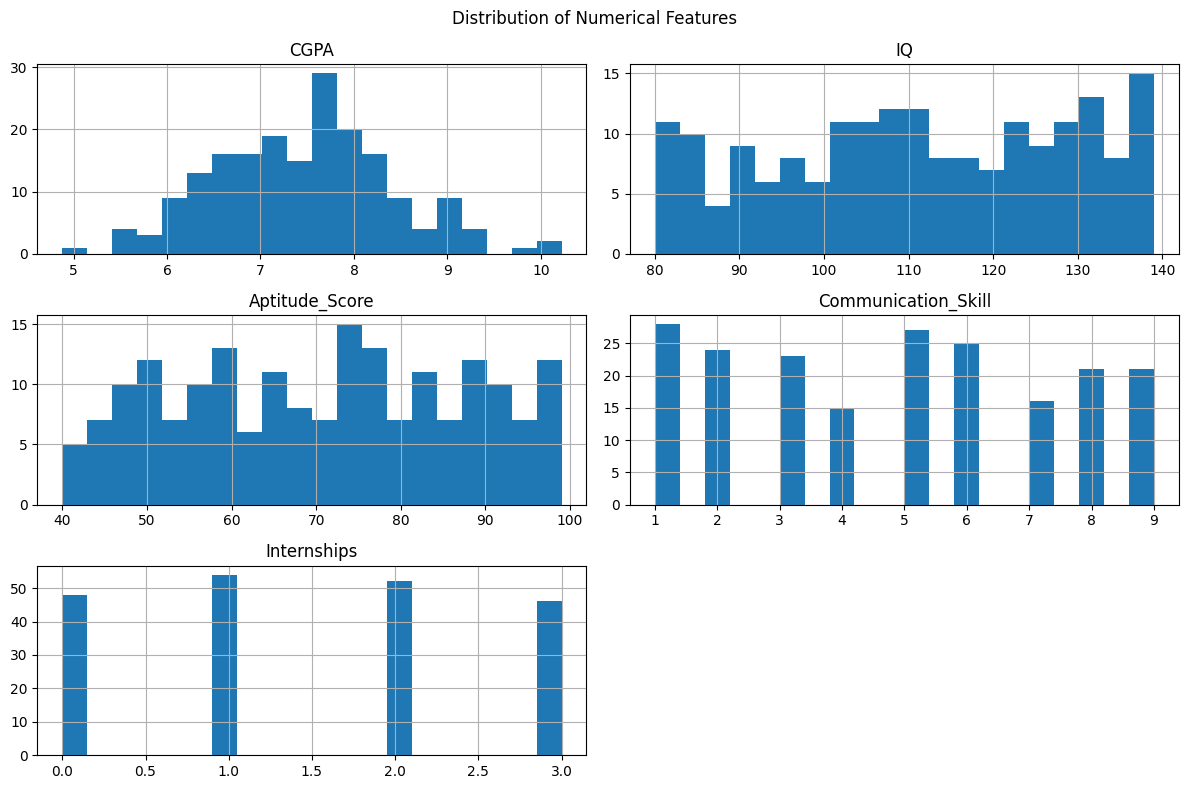

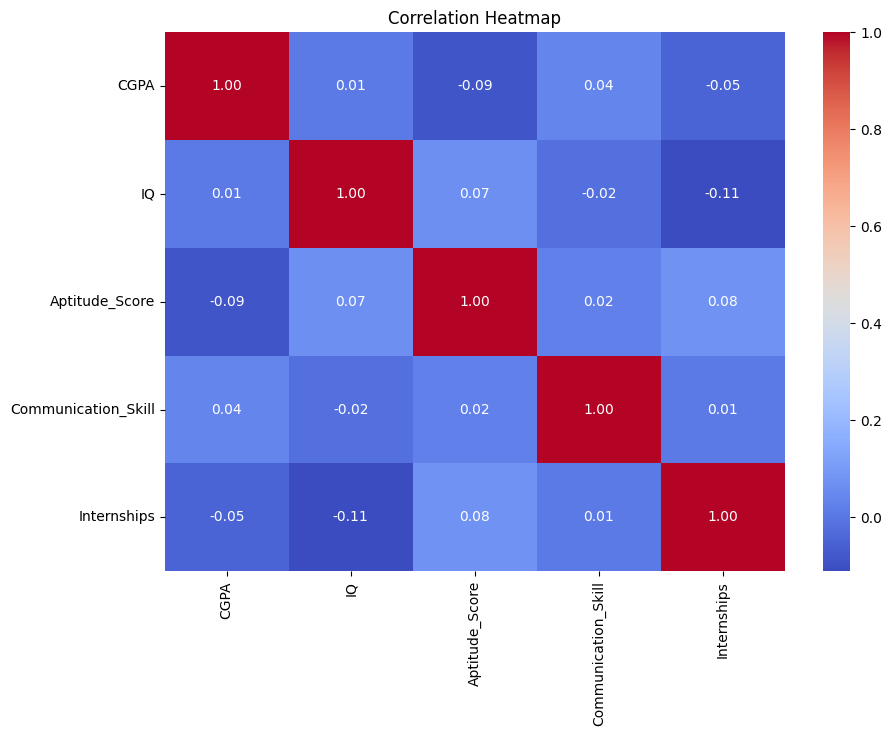

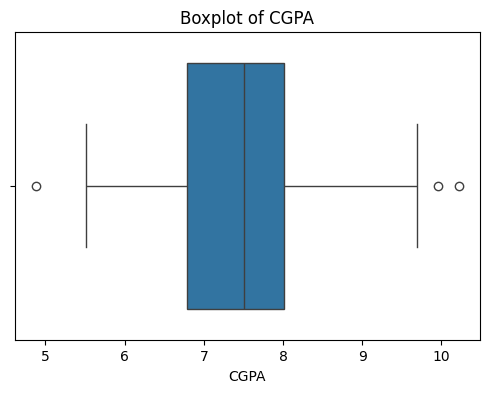

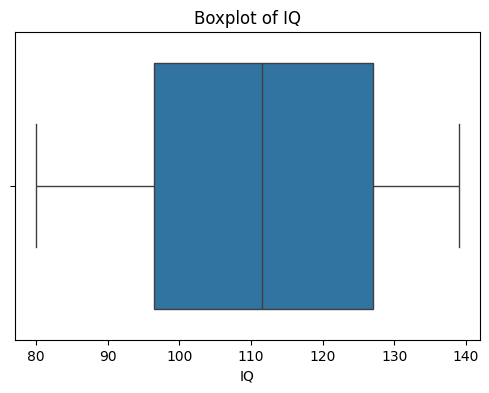

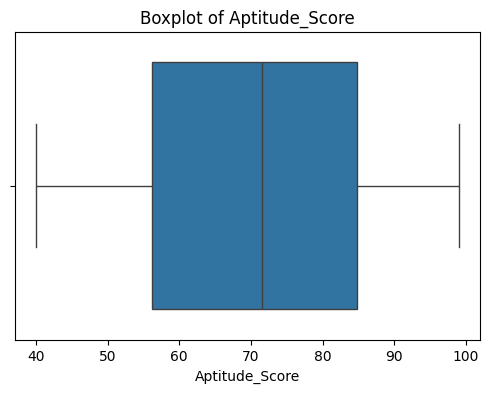

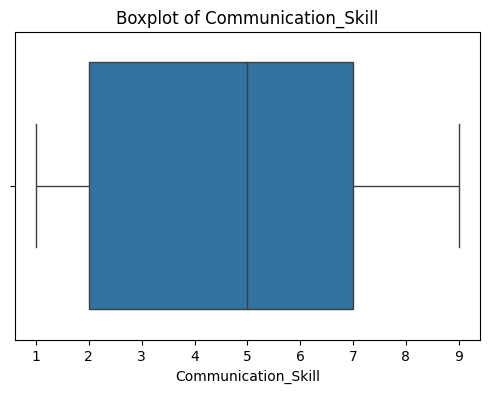

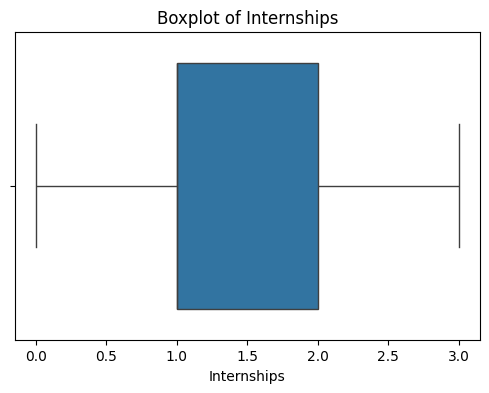


MISSING VALUE COUNT FEATURE CREATED

DATASET AFTER FEATURE ENGINEERING
   CGPA     IQ  Aptitude_Score  Communication_Skill  Internships Branch  \
0  8.00   81.0            89.0                    1            1   MECH   
1  7.36  105.0            74.0                    5            3  CIVIL   
2  8.15   96.0            62.0                    6            1     IT   
3  9.02  119.0            56.0                    6            2    CSE   
4   NaN    NaN             NaN                    3            3    CSE   

  Placed  Missing_Value_Count  
0     No                    0  
1    Yes                    0  
2     No                    0  
3     No                    0  
4    Yes                    3  

NEW DATASET SHAPE
(200, 8)

FEATURE ENGINEERING AND EDA COMPLETED


In [1]:
# EXPERIMENT 3
# Feature Engineering and EDA Project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Load Dataset
# --------------------------------------------------

df = pd.read_csv("placement_dataset.csv")

print("FIRST 5 ROWS")
print(df.head())


# --------------------------------------------------
# 2. Dataset Shape
# --------------------------------------------------

print("\nDATASET SHAPE")
print(df.shape)


# --------------------------------------------------
# 3. Column Information
# --------------------------------------------------

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)


# --------------------------------------------------
# 4. Missing Values
# --------------------------------------------------

print("\nMISSING VALUES")
print(df.isnull().sum())


# --------------------------------------------------
# 5. Duplicate Values
# --------------------------------------------------

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())


# --------------------------------------------------
# 6. Statistical Summary
# --------------------------------------------------

print("\nSTATISTICAL SUMMARY")
print(df.describe(include="all"))


# --------------------------------------------------
# 7. Numerical Columns
# --------------------------------------------------

numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("\nNUMERICAL COLUMNS")
print(numeric_columns.tolist())


# --------------------------------------------------
# 8. Histograms
# --------------------------------------------------

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 9. Correlation Heatmap
# --------------------------------------------------

plt.figure(figsize=(10, 7))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


# --------------------------------------------------
# 10. Boxplots
# --------------------------------------------------

for column in numeric_columns:

    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title("Boxplot of " + column)

    plt.show()


# --------------------------------------------------
# 11. Feature Engineering
# --------------------------------------------------

# Example: create an average academic score
academic_columns = []

for column in df.columns:

    if "CGPA" in column or "GPA" in column:
        academic_columns.append(column)

if len(academic_columns) >= 2:

    df["Average_Academic_Score"] = (
        df[academic_columns].mean(axis=1)
    )

    print("\nNEW FEATURE CREATED:")
    print("Average_Academic_Score")


# --------------------------------------------------
# 12. Missing Value Feature
# --------------------------------------------------

missing_count = df.isnull().sum(axis=1)

df["Missing_Value_Count"] = missing_count

print("\nMISSING VALUE COUNT FEATURE CREATED")


# --------------------------------------------------
# 13. Display Engineered Dataset
# --------------------------------------------------

print("\nDATASET AFTER FEATURE ENGINEERING")
print(df.head())

print("\nNEW DATASET SHAPE")
print(df.shape)


# --------------------------------------------------
# 14. Final Summary
# --------------------------------------------------

print("\nFEATURE ENGINEERING AND EDA COMPLETED")